<a href="https://colab.research.google.com/github/f26-sjsu-cmpe188/CA4/blob/main/xor_forward_propagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CA4 — Neural Networks: Architecture & Forward Pass

Learning Objectives:
* Describe the architecture of a multi-layer perceptron (layers, weight matrices, bias terms) and count trainable parameters.
* Trace a forward pass step by step through a small network, computing every intermediate value.

This notebook has three parts:
- **Part A** — a small network is *given* to you, fully solved by hand. You only run it forward — no training.
- **Part B** — train a network of the same structure and compare the learned weights to the hand-derived ones.
- **Part C** — change the number of hidden units and see what still works.

Prepared with the assistance of Claude (Anthropic); reviewed and verified by the instructor.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

## Load and visualize the dataset

`xor_wedge_20.csv` has 20 points split by two lines through the origin, `x2 = x1` and `x2 = -x1`,
into four wedges. Left/right wedges are labeled `+1`; top/bottom wedges are labeled `-1`. This is the same pattern we discussed in class. You are also provided a file `xor_wedge_test.csv` if you want to test the performance of this model on data it has never seen before.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/xor_wedge_20.csv")
print(df.shape)
df.head()

(20, 4)


,x1,x2,wedge,y
0,2.867,0.699,right,1
1,2.519,-0.134,right,1
2,2.447,0.792,right,1
3,1.238,0.215,right,1
4,1.783,-0.659,right,1


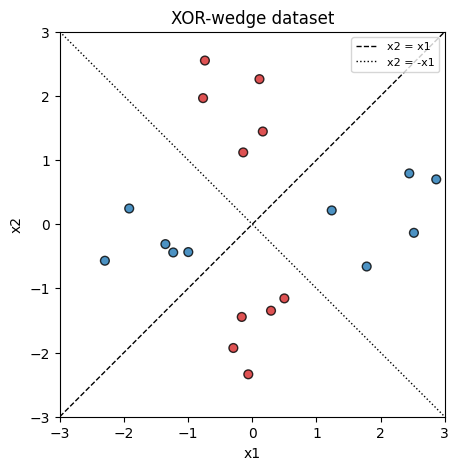

In [ ]:
def plot_dataset(df, ax=None, title="XOR-wedge dataset"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    colors = ['tab:blue' if y == 1 else 'tab:red' for y in df['y']]
    ax.scatter(df['x1'], df['x2'], c=colors, s=40, edgecolor='k', alpha=0.8)


    # overlay the two separator lines
    lim = np.array([-3, 3])
    ax.plot(lim, lim, 'k--', lw=1, label='x2 = x1')
    ax.plot(lim, -lim, 'k:', lw=1, label='x2 = -x1')

    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=8)
    ax.set_aspect('equal')
    return ax

plot_dataset(df)
plt.show()

**Look at the plot.** Blue (`+1`) sits in the left/right wedges; red (`-1`) sits in the top/bottom wedges.
No single straight line separates blue from red — that's the point of today's activity.

---

## Part A — Forward Propagation Only, By Hand

The network below is **given** — you are not training anything in this part. All three layers use
**sign activation**: output `+1` if the signal is `>= 0`, else `-1`.

- **Hidden layer 1** (`h1, h2`): each unit is one of the two separator lines, written as a weight
  vector the same way `Class notes 9_1.txt` converts a line to `w = [w0, w1, w2]`.
- **Hidden layer 2** (`u1, u2`): each unit is a bipolar AND gate combining `h1, h2` (`AND(a,b) = sign(a+b-1)`).
- **Output layer**: a bipolar OR gate combining `u1, u2` (`OR(a,b) = sign(a+b+1)`).

See the README table for exactly how each weight vector was derived.


In [ ]:
def sign(s):
    return np.where(s >= 0, 1, -1)

# Hidden layer 1: two lines as weight vectors [w0, w1, w2] (input = [1, x1, x2])
W1 = np.array([
    [0, -1, 1],   # h1: line x2 = x1
    [0,  1, 1],   # h2: line x2 = -x1
])

# Hidden layer 2: bipolar AND gates combining (h1, h2) -> [w0, w1, w2] (input = [1, h1, h2])
W2 = np.array([
    [-1,  1, -1],  # u1 = h1 AND (NOT h2)
    [-1, -1,  1],  # u2 = (NOT h1) AND h2
])

# Output layer: bipolar OR gate combining (u1, u2) -> [w0, w1, w2] (input = [1, u1, u2])
W3 = np.array([
    [1, 1, 1],     # out = u1 OR u2
])


def augment(x):
    """x: (N, d) -> (N, d+1) with a leading column of 1s for the bias."""
    ones = np.ones((x.shape[0], 1))
    return np.hstack([ones, x])


def forward_hand_built(x1, x2):
    """Runs the hand-derived 2->2->2->1 network. Returns every intermediate value."""
    x = np.column_stack([x1, x2])

    s1 = augment(x) @ W1.T          # (N, 2): [s_h1, s_h2]
    h = sign(s1)                     # (N, 2): [h1, h2]

    s2 = augment(h) @ W2.T          # (N, 2): [s_u1, s_u2]
    u = sign(s2)                     # (N, 2): [u1, u2]

    s3 = augment(u) @ W3.T          # (N, 1): [s_out]
    out = sign(s3).ravel()

    return {"s1": s1, "h": h, "s2": s2, "u": u, "s3": s3, "out": out}

In [ ]:
result = forward_hand_built(df['x1'].values, df['x2'].values)
df['y_pred_handbuilt'] = result['out']

accuracy = accuracy_score(df['y'], df['y_pred_handbuilt'])
print(f"Hand-built network accuracy on all 20 points: {accuracy:.2f}")
df[['x1', 'x2', 'wedge', 'y', 'y_pred_handbuilt']]

Hand-built network accuracy on all 20 points: 1.00


,x1,x2,wedge,y,y_pred_handbuilt
0,2.867,0.699,right,1,1
1,2.519,-0.134,right,1,1
2,2.447,0.792,right,1,1
3,1.238,0.215,right,1,1
4,1.783,-0.659,right,1,1
5,0.164,1.445,top,-1,-1
6,-0.767,1.965,top,-1,-1
7,-0.141,1.119,top,-1,-1
8,-0.738,2.551,top,-1,-1
9,0.112,2.261,top,-1,-1


### Hand-worked examples (base question A.2)

Pick row numbers ending in your SJSU ID % 10, i.e., the last digit of your SJSU ID and show every intermediate value (`s1 -> h -> s2 -> u -> s3 -> out`)
in a markdown cell, the way you would on paper. The code cell below prints those same intermediate values for those points — use it to check your by-hand arithmetic, not to skip doing it.


In [ ]:
row_numbers = [1,2]
your_points = df.iloc[row_numbers]

for _, row in your_points.iterrows():
    r = forward_hand_built(np.array([row['x1']]), np.array([row['x2']]))
    print(f"--- wedge={row['wedge']}  point=({row['x1']:.2f}, {row['x2']:.2f})  true y={row['y']} ---")
    print(f"  s1 (signals into h1,h2) = {r['s1'][0]}")
    print(f"  h  (h1,h2 after sign)   = {r['h'][0]}")
    print(f"  s2 (signals into u1,u2) = {r['s2'][0]}")
    print(f"  u  (u1,u2 after sign)   = {r['u'][0]}")
    print(f"  s3 (signal into output) = {r['s3'][0]}")
    print(f"  predicted y             = {r['out'][0]}")
    print()

--- wedge=right  point=(2.52, -0.13)  true y=1 ---
  s1 (signals into h1,h2) = [-2.653  2.385]
  h  (h1,h2 after sign)   = [-1  1]
  s2 (signals into u1,u2) = [-3.  1.]
  u  (u1,u2 after sign)   = [-1  1]
  s3 (signal into output) = [1.]
  predicted y             = 1

--- wedge=right  point=(2.45, 0.79)  true y=1 ---
  s1 (signals into h1,h2) = [-1.655  3.239]
  h  (h1,h2 after sign)   = [-1  1]
  s2 (signals into u1,u2) = [-3.  1.]
  u  (u1,u2 after sign)   = [-1  1]
  s3 (signal into output) = [1.]
  predicted y             = 1



**TODO (write-up):** For the points assigned to you, write out the full by-hand computation
(every intermediate number, not just the final answer) in a markdown cell here.

Student ID: 018793021
=> assigned poin (2.519, -0,134)

**Hand calculation is attached in PDF**

### Discussion (optional questions A.3 and A.4)

**A.3** — Looking at the plot at the top of this notebook: why does the region "between" the two
lines (left/right wedges) end up a different class than the region "outside" them (top/bottom
wedges)? Why does that pattern defeat any single straight-line classifier?

*Your answer:*

**A.4** — Count the trainable parameters in this network, layer by layer (weights + biases). Then
explain why `h1, h2` alone, fed straight into a single weighted-sum output unit, could **not**
solve this task — why did we need the second hidden layer (`u1, u2`)?

*Your answer:*


In [ ]:
# helper for A.4 — count parameters layer by layer
for name, W in [("layer 1 (h1,h2)", W1), ("layer 2 (u1,u2)", W2), ("layer 3 (out)", W3)]:
    n_weights = W[:, 1:].size
    n_biases = W[:, 0].size
    print(f"{name}: {n_weights} weights + {n_biases} biases = {n_weights + n_biases} parameters")

layer 1 (h1,h2): 4 weights + 2 biases = 6 parameters
layer 2 (u1,u2): 4 weights + 2 biases = 6 parameters
layer 3 (out): 2 weights + 1 biases = 3 parameters


---

## Part B — Train the Same Structure and Compare

Now train an `MLPClassifier` with the same shape (two hidden layers of two units each) on this
dataset, and compare what gradient descent finds to the hand-built weights above.

**A note on `solver` and `random_state`:** with only 20 training points, sklearn's default solver
(`adam`) is unreliable — try it and you may see training accuracy well below 100%, not because the
network *can't* solve this task, but because gradient descent got stuck. `solver='lbfgs'` (which
sklearn recommends for small datasets) does much better, but even it can land in a bad local
minimum depending on `random_state`. **If your training accuracy isn't near 1.0, try a few
different `random_state` values before concluding anything** — this is itself worth noticing, and
Part C comes back to it.


In [ ]:
y01 = ((df['y'] + 1) // 2).astype(int)  # remap {-1,+1} -> {0,1}
X = df[['x1', 'x2']].values

clf = MLPClassifier(
    hidden_layer_sizes=(2, 2),
    activation='tanh',
    solver='lbfgs',
    max_iter=5000,
    random_state=0,
)
clf.fit(X, y01)

train_acc = clf.score(X, y01)
print(f"MLPClassifier(2,2) training accuracy: {train_acc:.2f}")

MLPClassifier(2,2) training accuracy: 1.00


In [ ]:
print("Trained weights (clf.coefs_) and biases (clf.intercepts_):\n")
for i, (Wc, bc) in enumerate(zip(clf.coefs_, clf.intercepts_), start=1):
    print(f"Layer {i} weights:\n{np.round(Wc, 2)}")
    print(f"Layer {i} biases:  {np.round(bc, 2)}\n")

print("Compare to the hand-derived weights above (W1, W2, W3) — same shapes, different numbers.")

Trained weights (clf.coefs_) and biases (clf.intercepts_):

Layer 1 weights:
[[ 8.59  3.93]
 [-6.47  4.81]]
Layer 1 biases:  [ 1.93 -0.2 ]

Layer 2 weights:
[[-2.5   7.48]
 [ 3.6  -5.25]]
Layer 2 biases:  [4.02 5.96]

Layer 3 weights:
[[8.67]
 [8.69]]
Layer 3 biases:  [-8.67]

Compare to the hand-derived weights above (W1, W2, W3) — same shapes, different numbers.


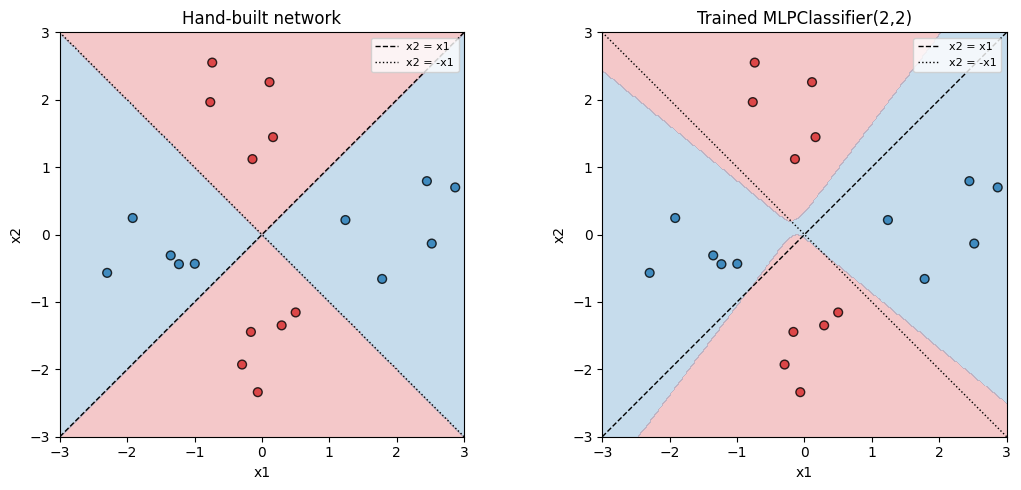

In [ ]:
def plot_boundary(clf_or_fn, df, ax=None, title="Decision boundary", is_sklearn=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    xx, yy = np.meshgrid(np.linspace(-3, 3, 300), np.linspace(-3, 3, 300))
    grid = np.column_stack([xx.ravel(), yy.ravel()])

    if is_sklearn:
        zz = clf_or_fn.predict(grid).reshape(xx.shape)
    else:
        zz = clf_or_fn(grid[:, 0], grid[:, 1])['out'].reshape(xx.shape)

    ax.contourf(xx, yy, zz, levels=1, alpha=0.25, colors=['tab:red', 'tab:blue'])
    plot_dataset(df, ax=ax, title=title)
    return ax

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_boundary(forward_hand_built, df, ax=axes[0], title="Hand-built network", is_sklearn=False)
plot_boundary(clf, df, ax=axes[1], title="Trained MLPClassifier(2,2)")
plt.tight_layout()
plt.show()

### Discussion (base question B.4)

Both networks get 100% accuracy on this dataset, but the weights look nothing alike. Give at
least two concrete reasons trained weights don't have to match a hand-derived solution (think
about: relabeling which hidden unit is "first," sign flips, gradient descent landing in a
different but equally valid solution, and how `tanh` vs. `sign` changes what "correct" weight
magnitudes even look like).

*Your answer:*

1. Different way of finding weights:

    The MLP starts with random weights and uses an optimizer, such as gradient descent, to update the weights and reduce the loss. This is different from my hand-built solution, where I looked at the function and manually assigned weights to create the desired boundaries.
2. Relabeling hidden units:

    The MLP does not care which hidden neuron is called neuron 1 or neuron 2. Because the neurons start with random weights, the order of the learned hidden units may not correspond to the order in my hand-built solution.

---

## Part C — Does the Number of Hidden Units Matter?

Part B's note about `random_state` sensitivity was a hint: whether a network *can* solve this task
in principle, and how *reliably* gradient descent actually finds a solution, are two different
questions. Here we check both, for three architectures: `(2,2)` (Part A/B's structure), `(4,)` (a
single wider hidden layer), and `(2,)` (a single hidden layer the same size as Part A's first
layer, but with no second hidden layer before the output).


In [ ]:
architectures = [(2, 2), (4,), (2,)]
N_SEEDS = 15

reliability_rows = []
best_seed_per_arch = {}

for arch in architectures:
    accs = []
    for seed in range(N_SEEDS):
        clf_c = MLPClassifier(hidden_layer_sizes=arch, activation='tanh', solver='lbfgs',
                               max_iter=5000, random_state=seed)
        clf_c.fit(X, y01)
        accs.append(clf_c.score(X, y01))
    accs = np.array(accs)
    reliability_rows.append({
        "hidden_layer_sizes": arch,
        "mean_train_accuracy": accs.mean(),
        "success_rate (acc >= 0.95)": (accs >= 0.95).mean(),
        "best_seed": int(np.argmax(accs)),
    })
    best_seed_per_arch[arch] = int(np.argmax(accs))

reliability_df = pd.DataFrame(reliability_rows)
reliability_df

,hidden_layer_sizes,mean_train_accuracy,success_rate (acc >= 0.95),best_seed
0,"(2, 2)",0.903333,0.666667,0
1,"(4,)",1.000000,1.000000,0
2,"(2,)",0.910000,0.666667,0


**Look at `success_rate` above.** This is optional question C.1: across `N_SEEDS` random
restarts, what fraction of the time did each architecture reach (near) 100% training accuracy?


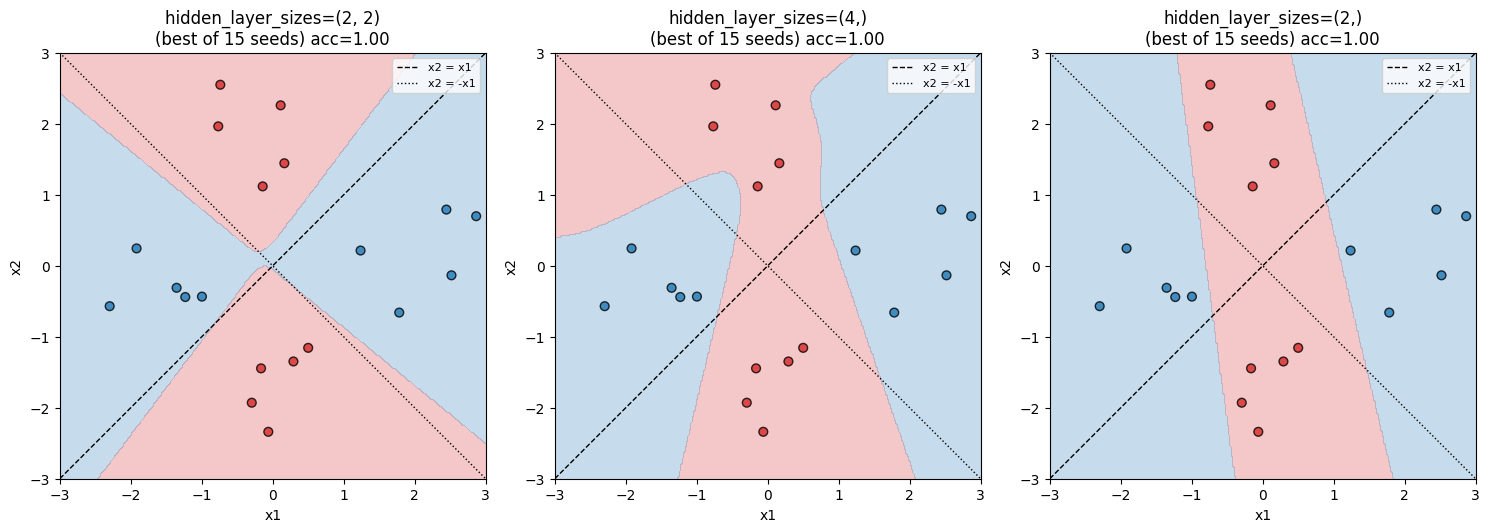

In [ ]:
fig, axes = plt.subplots(1, len(architectures), figsize=(5 * len(architectures), 5))

for ax, arch in zip(axes, architectures):
    seed = best_seed_per_arch[arch]
    clf_c = MLPClassifier(hidden_layer_sizes=arch, activation='tanh', solver='lbfgs',
                           max_iter=5000, random_state=seed)
    clf_c.fit(X, y01)
    acc = clf_c.score(X, y01)
    plot_boundary(clf_c, df, ax=ax, title=f"hidden_layer_sizes={arch}\n(best of {N_SEEDS} seeds) acc={acc:.2f}")

plt.tight_layout()
plt.show()

The plots above (question C.2) show each architecture's **best** run out of `N_SEEDS`
random restarts — useful for seeing what a successful solution's boundary looks like, but remember
the reliability table above already told you how often each architecture actually gets there.

### Discussion (optional question C.4)

Connect this to the "more nodes -> more approximation power, less generalization" idea from
lecture, *and* to the "$E_{in}$ is not smooth, so gradient descent can land in different local
minima" idea from the neural-networks slides. Based on the reliability table above:
- Which architecture was most reliable, and which was least? Is that the same ranking you'd expect
  from parameter count alone?
- Does `(2,)` — a single hidden layer with no second hidden layer — ever reach 100% accuracy? If
  so, does that contradict what you argued in Part A.4 about needing a second hidden layer? (Hint:
  the hidden units a trained network finds don't have to be the same two lines, `x2=x1` and
  `x2=-x1`, that Part A used.)
- What's the smallest hidden-layer structure you'd recommend for this dataset if you cared about
  **reliably** getting a good solution, not just whether one exists?

*Your answer:*
